### Multithreading
In Java ci sono due modi per creare thread:
1. **estendere la classe `Thread`**
2. **implementare l'interfaccia `Runnable`**

In [ ]:
void doSomething() {
    System.out.println("Faccio qualcosa...");
}

public class MyThread extends Thread {
	@Override
	public void run(){
		doSomething();
	}
}

Thread t = new MyThread();
t.start();
t.join();

In [ ]:
void doSomething() {
    System.out.println("Faccio qualcosa...");
}

public class MyRunnable implements Runnable {
	@Override
	public void run(){
		doSomething();
	}
}

Runnable r = new MyRunnable(); // polimorfismo
Thread t = new Thread(r);
t.start();
t.join();

La classe `Thread` richiede una classe che implementi `Runnable` (cioè che abbia il metodo `run()`).

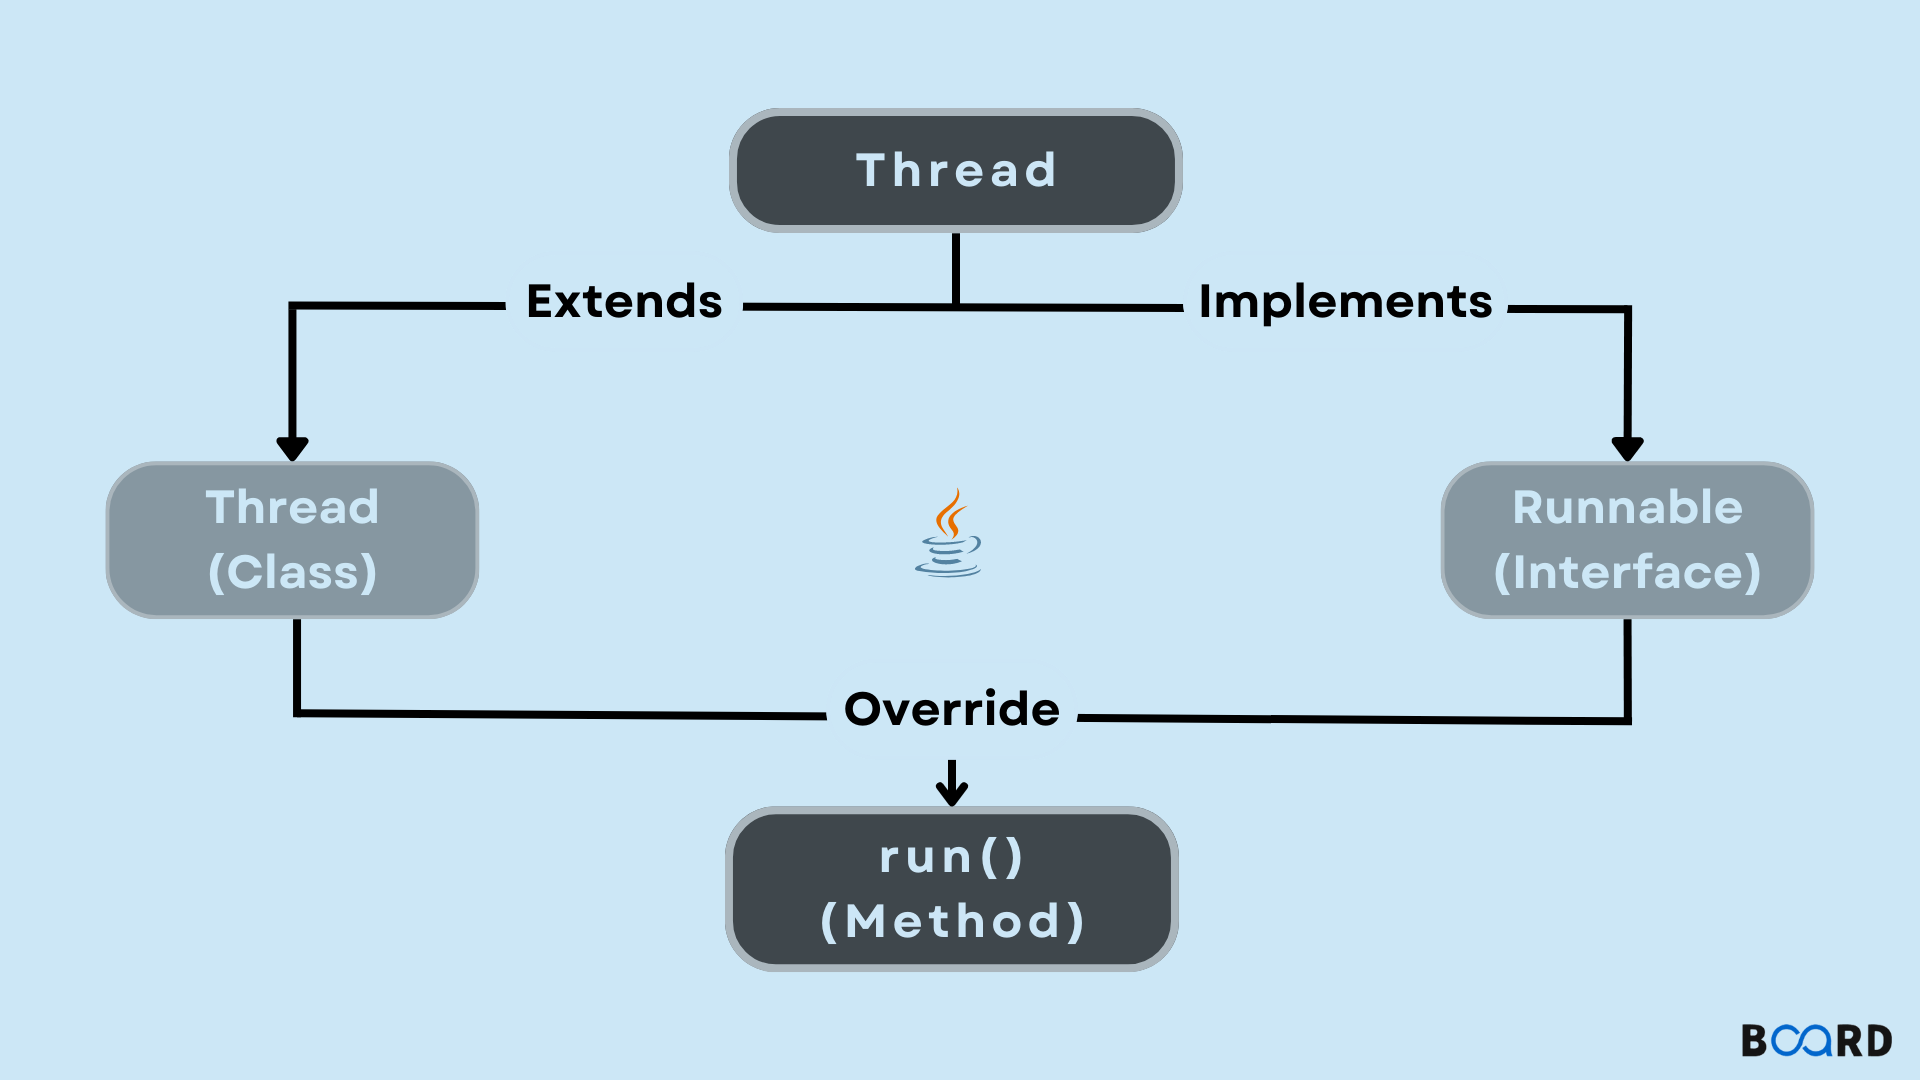

I due approcci esistono perché **Java non permette l'ereditarietà multipla**: se la classe deve già estendere un'altra classe, non può estendere anche `Thread`, quindi si passa all'approccio `Runnable`.

> *Regola pratica: se non devi ereditare da nient'altro, `extends Thread` va bene; in tutti gli altri casi (e in generale per buon design, separando "cosa fare" dal "come eseguirlo") si preferisce `implements Runnable`.*

I thread di uno stesso processo **condividono**:
- la **method area**
- l'**heap**

mentre **ognuno ha il proprio**:
- **stack**
- **program counter**

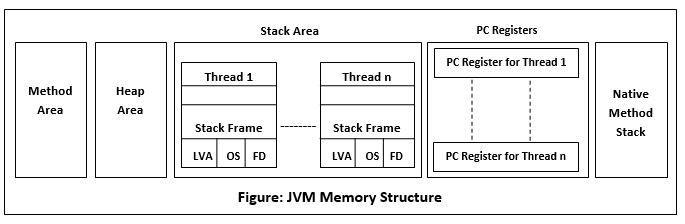

#### Metodi principali della classe `Thread`
- `start()` - alloca il thread nella JVM e chiama `run()`
- `sleep(long ms)` - sospende il thread per `ms` millisecondi
- `yield()` - cede la CPU a un altro thread con la stessa priorità (vedi dopo)
- `interrupt()` - segnala al thread di interrompersi
- `join()` - il thread chiamante aspetta la fine di un altro thread
- `wait()` - sospende il thread e **rilascia il monitor**, in attesa di un `notify()` da parte di un altro thread (deve essere chiamata dentro un blocco `synchronized`) → vedi dopo

> *Attenzione: si chiama sempre `start()`, mai `run()` direttamente. Chiamare `run()` esegue il codice nel thread corrente, senza creare un nuovo thread.*

Differenza tra `yield()` e `interrupt()`: la differenza sta nel **chi chiama** e **cosa succede dopo**.

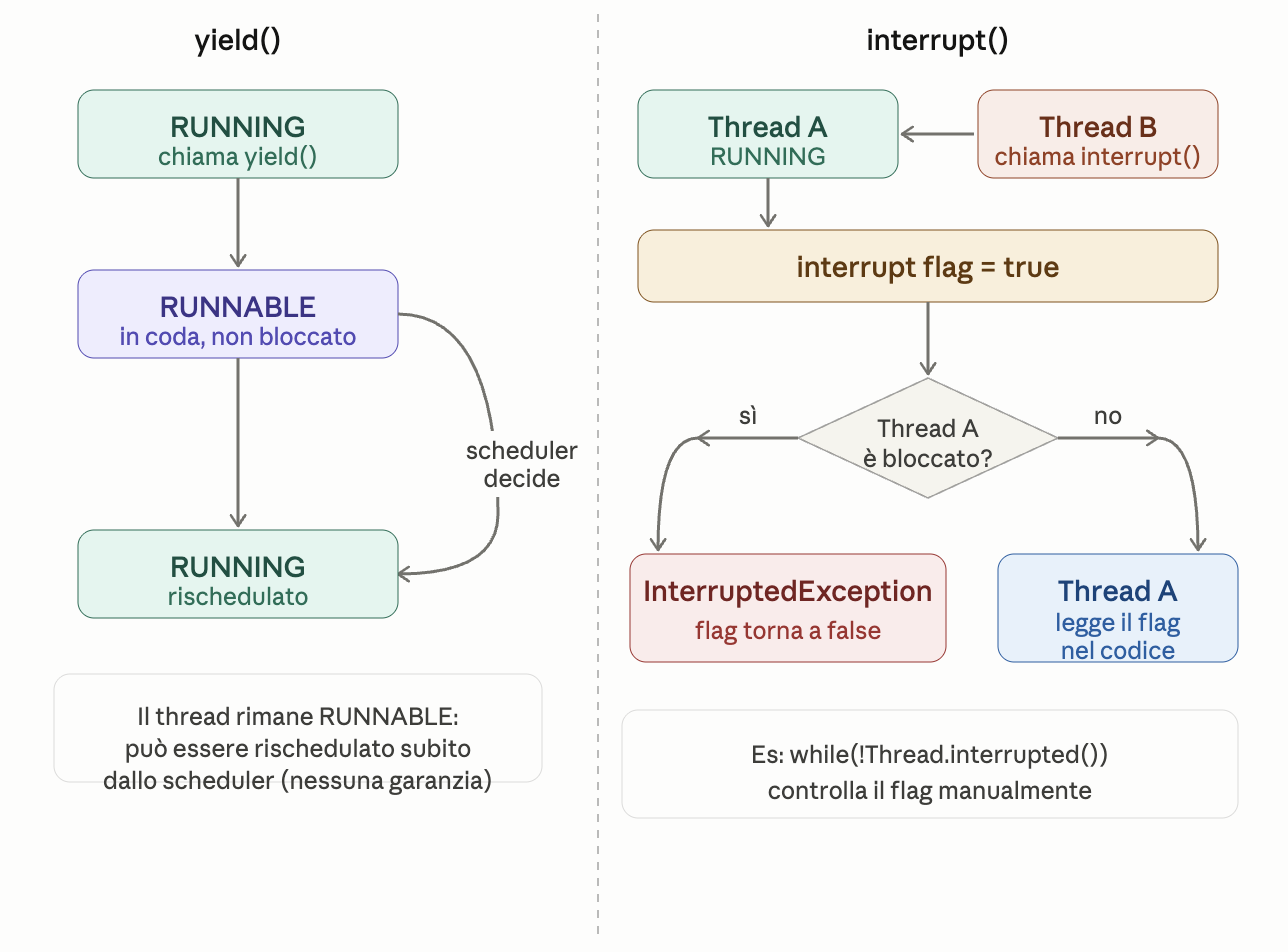

Nel caso dell'eccezione, essa non viene "chiamata da sola": va **gestita** in un costrutto `try`/`catch` che circonda un metodo in grado di sollevarla.

> *Esempio: `Thread.sleep()`, `wait()` e `join()` dichiarano `throws InterruptedException`, quindi devono per forza essere racchiusi in un `try`/`catch`.*

Per gestire invece il flag nel codice ci sono 2 strade:
- `Thread.interrupted()` → metodo **statico**, lo chiami sulla classe (vale per il thread corrente che sta eseguendo) e **resetta il flag** a `false`.
- dato `t : Thread` → `t.isInterrupted()` → è un **getter**, **non resetta il flag**; puoi anche usare `this.isInterrupted()`.

In [ ]:
void doHeavyWork() {
    System.out.println("Sto lavorando... (" + Thread.currentThread().getName() + ")");
}

public class Worker extends Thread {
    @Override
    public void run() {
        while (!Thread.interrupted()) {        // check del flag nel codice
            try {
                doHeavyWork();
                Thread.sleep(1000);            // può sollevare InterruptedException
            } catch (InterruptedException e) {
                // sleep() ha già azzerato il flag: lo ri-imposto per uscire dal while
                Thread.currentThread().interrupt();
            }
        }
        System.out.println("Thread interrotto, esco pulito.");
    }
}

Thread worker = new Worker();
worker.start();
new Thread(() -> worker.interrupt()).start();

worker.join();

> *Nota: quando `sleep()`/`wait()` sollevano `InterruptedException`, il flag viene riportato a `false`. Se vuoi propagare l'interruzione lo devi re-impostare con `interrupt()` nel `catch`, come sopra.*

Da questa differenza tra `yield()` e `interrupt()` ci colleghiamo agli stati di un thread.

#### Stati di thread

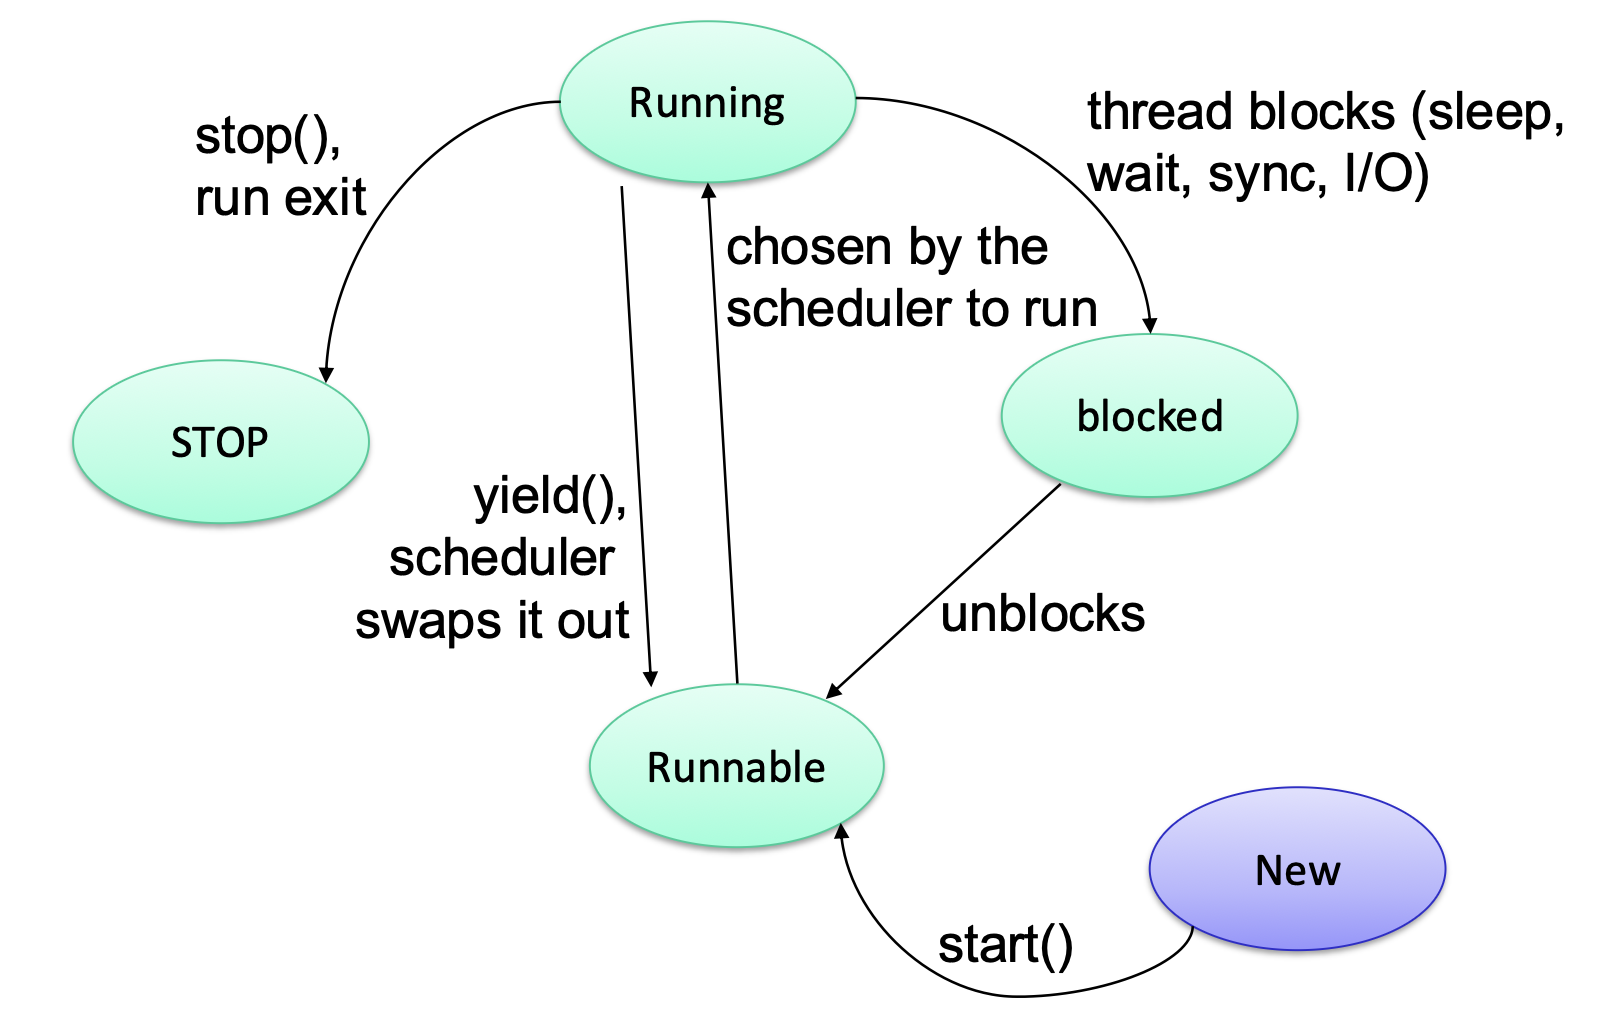


| Stato | EntryPoint | Blocked | Interruptible | Description |
|---|---|---|---|---|
| **Running** | lo scheduler seleziona il thread tra i `Runnable` | No | — | il thread sta effettivamente usando la CPU |
| **Runnable** | `start()`, oppure ritorno da uno stato di blocco | No | — | pronto a eseguire, in attesa che lo scheduler gli assegni la CPU |
| **Sleeping** | `sleep(long ms)` | Sì | Sì (lancia `InterruptedException`) | sospeso per un tempo definito; non rilascia i mutex che possiede |
| **Waiting** | `wait()`, `join()` | Sì | Sì (lancia `InterruptedException`) | attesa "volontaria" di un evento; `wait()` **rilascia il monitor**, `join()` attende la fine di un altro thread |
| **Blocked I/O** | chiamata a un'operazione di I/O bloccante | Sì | dipende dall'implementazione | in attesa del completamento di un'operazione di input/output |
| **Blocked synch** | accesso a un blocco/metodo `synchronized` già occupato | Sì | No | in coda per acquisire un mutex già detenuto da un altro thread |


La differenza tra **Waiting** e **Blocked synch** è che in `Waiting` il thread ci entra **"volontariamente"**, ossia dopo la chiamata di `wait()` o `join()`, mentre in `Blocked synch` ci entra **involontariamente**, se accede a un blocco `synchronized` già occupato.

#### Priorità
Riguardo alla frase detta prima:

> yield() - Cede la cpu a un altro thread **con la stessa priorità**

Ogni thread ha una **priorità**, da 1 (`MIN_PRIORITY`) a 10 (`MAX_PRIORITY`), con default 5 (`NORM_PRIORITY`).

Un thread **eredita la priorità del thread che lo crea**, altrimenti si può impostare con `setPriority(int)`.

La specifica Java prevede l'algoritmo **"fixed priority scheduling"**, basato sulle priorità dei thread:
- **priorità diversa** → il thread a priorità più alta va prima
- **stessa priorità** → FCFS (First Come First Served)

Cioè un certo thread può continuare l'esecuzione finché:
1. un thread a **priorità più alta** diventa `Runnable`
2. invoca `yield()` oppure finisce `run()`
3. in un OS a **time slicing** finisce il tempo a sua disposizione
4. passa da `Running` a `Blocked`

> le priorità sono un suggerimento allo scheduler, non una garanzia. Non usarle per garantire la correttezza del programma.

> Non usare il time slicing come certezza su cui basare i programmi: questo tipo di scheduling non è disponibile in tutti i sistemi operativi e architetture.

Un problema sono i **selfish threads**, cioè quelli che non cedono mai il flusso a colleghi con la stessa priorità. Non potendo fare affidamento sul time slicing (ragionando nel **worst-case**), una buona pratica è, se il task è particolarmente CPU-intensive, lasciare il controllo con `yield()` oppure effettuare una `sleep()`.

### Meccanismi di sincronizzazione
Java offre vari meccanismi di sincronizzazione:
- **mutex** (`synchronized`)
- **monitor "built-in"** (mutex + `wait` + `notify`)
- **Java > 1.5** (`java.util.concurrent`):
	- `Semaphore` (`acquire`, `release`, `tryAcquire`)
	- `Lock` (`lock`, `unlock`, `tryLock`)
	- `Condition` (`await`, `signal`)

#### Mutex
Ogni oggetto in Java ha un **mutex** (lock intrinseco), a cui si accede tramite:
1. **metodi sincronizzati**
2. **blocchi sincronizzati**

1
```java
public synchronized void Method(…){
	doSomething();
}
```

2
```java
public void Method(…){
	synchronized (this) {
		doSomething();
	}
}
```

Quando un thread esegue un metodo o un blocco dichiarato `synchronized`:
- entra in **possesso del mutex** associato all'istanza
- finché tiene il mutex ha **accesso esclusivo** a tutte le sezioni critiche di quell'istanza
- eventuali thread che vogliano acquisire lo stesso mutex, per accedere a qualsiasi sezione critica di quell'istanza, vengono posti in **stato di attesa** (`Blocked synch`)

> **Nota**: i metodi o i blocchi `synchronized` garantiscono l'accesso in mutua esclusione ai dati incapsulati in un oggetto **se e solo se** si accede a quei dati con metodi o blocchi dichiarati `synchronized`.

Possono essere `synchronized` anche i **metodi statici**: in quel caso viene acquisito il **mutex legato alla classe** (l'oggetto `Class`), distinto da quello delle istanze:

- Se invochiamo **due metodi statici** sincronizzati di una stessa classe da due thread diversi, vengono eseguiti **in sequenza** (stesso mutex di classe).
- Se invochiamo **un metodo statico e uno d'istanza**, entrambi sincronizzati, da due thread diversi, vengono eseguiti **in concorrenza** (mutex diversi: uno di classe, uno di istanza).

In [ ]:
public class Counter {
    // stato d'istanza — ogni oggetto Counter ha il suo
    private int instanceCount = 0;

    // stato statico — condiviso tra tutti gli oggetti Counter
    private static int staticCount = 0;

    // lock: this (l'istanza specifica)
    public synchronized void incrementInstance() {
        instanceCount++;
        System.out.println(Thread.currentThread().getName()
            + " → instanceCount = " + instanceCount);
    }

    // lock: Counter.class (unico per tutta la classe)
    public static synchronized void incrementStatic() {
        staticCount++;
        System.out.println(Thread.currentThread().getName()
            + " → staticCount  = " + staticCount);
    }
}

// --- due istanze distinte ---
Counter c1 = new Counter();
Counter c2 = new Counter();

// metodi d'istanza: c1 e c2 hanno lock DIVERSI → girano in parallelo senza bloccarsi
Thread t1 = new Thread(() -> { for (int i = 0; i < 3; i++) c1.incrementInstance(); }, "T1-c1");
Thread t2 = new Thread(() -> { for (int i = 0; i < 3; i++) c2.incrementInstance(); }, "T2-c2");

System.out.println("=== metodo d'istanza (lock per oggetto) ===");
t1.start();
t2.start();
t1.join();
t2.join();

// metodo statico: lock unico → T3 e T4 si escludono a vicenda
Thread t3 = new Thread(() -> { for (int i = 0; i < 3; i++) Counter.incrementStatic(); }, "T3");
Thread t4 = new Thread(() -> { for (int i = 0; i < 3; i++) Counter.incrementStatic(); }, "T4");

System.out.println("=== metodo statico (lock di classe) ===");
t3.start();
t4.start();
t3.join();
t4.join();

***La cosa interessante da osservare:** nella sezione d'istanza T1 e T2 possono alternarsi liberamente (lock diversi, non si bloccano a vicenda), mentre nella sezione statica uno dei due thread completa tutte le iterazioni prima che l'altro parta — o comunque non si sovrappongono mai.*

> **Nota**: `synchronized` è **rientrante** (reentrant, ricorsivo), nel senso che **lo stesso thread può riacquisire un lock che già possiede**, senza bloccarsi.

Questo esempio chiarisce perché in realtà questa caratteristica è tanto necessaria quanto scontata:

```java
class Esempio {
    synchronized void metodoA() {
        metodoB(); // chiama un altro metodo synchronized
    }

    synchronized void metodoB() {
        // fa qualcosa
    }
}
```

Per entrare in `metodoB()` il thread dovrebbe acquisire lo **stesso mutex** che già detiene per `metodoA()`: **senza rientranza andrebbe in deadlock garantito** (aspetterebbe sé stesso).

#### Dettaglio sui blocchi sincronizzati

I blocchi sincronizzati hanno **pro** e **contro**:
- **pro**: quando c'è bisogno che una **sequenza** di operazioni su un oggetto sia **atomica**, cioè non interrompibile tra un'operazione e l'altra, i metodi sincronizzati non bastano perché il mutex dell'istanza viene comunque **rilasciato tra una chiamata e l'altra**. La soluzione è usare un blocco sincronizzato che avvolga tutta la sequenza:

```java
synchronized (object) {
	object.op1();
	object.op2();
}
```

- **contro**: utilizzare i blocchi sincronizzati crea una **decentralizzazione delle responsabilità**. I vincoli di sincronizzazione associati a un oggetto `O` non sono più incapsulati in un unico posto, quindi bisogna cercare **tutti i punti** in cui si accede a quell'oggetto `O` e verificare che si usi `synchronized`.

> ***Trade-off:** i blocchi danno granularità e atomicità su sequenze, ma spostano la responsabilità della correttezza sul chiamante invece di tenerla incapsulata nell'oggetto.*

#### Monitor built-in
In Java, una classe con metodi `synchronized` è di fatto un **monitor**: combina il **mutex** (mutua esclusione) con i metodi `wait()` / `notify()` (sincronizzazione condizionale). Un monitor Java è **sempre signal-and-continue** (chi fa la `notify()` continua a eseguire e mantiene il monitor; il thread risvegliato deve ri-acquisirlo) e ha **una sola, implicita, condition variable**.

Lo schema tipico di un metodo di monitor è il seguente:

```java
public synchronized void Method(){
	while(!condition){           // sempre while, mai if
		try { wait(); }
		catch (InterruptedException e){
			// [...]
		}
	}
	// [operation]
	notify(); // oppure notifyAll()
}
```

> **Perché `while` e non `if`?** Quando il thread viene risvegliato deve **ri-controllare** la condizione: tra la `notify()` e l'effettivo ri-acquisto del monitor un altro thread potrebbe averla resa di nuovo falsa (è la natura del signal-and-continue), e ci sono anche i cosiddetti *spurious wakeup*. Con `if` il thread proseguirebbe sbagliando; con `while` ricontrolla e, se serve, torna in attesa.

> **Nota**: `wait()`, `notify()` e `notifyAll()` vanno chiamate **dentro un blocco/metodo `synchronized`** sullo stesso oggetto, altrimenti si ottiene una `IllegalMonitorStateException`. Inoltre `wait()` **rilascia il monitor** mentre il thread è sospeso (a differenza di `sleep()`, che lo trattiene).

Le varianti disponibili sono:

`wait()`:
- `wait()` → attesa senza limite di tempo
- `wait(long millis)` → attesa con **timeout** in millisecondi
- `wait(long millis, int nanos)` → timeout a risoluzione più fine; il tempo totale di attesa è la **somma** dei due argomenti

`notify()`:
- `notify()` → risveglia **un solo** thread (non deterministico) nel wait set del monitor
- `notifyAll()` → risveglia **tutti** i thread nel wait set; tra quelli che tornano `Runnable`, lo scheduler eseguirà per primo quello (se c'è) a **priorità più alta**

> *In pratica si preferisce quasi sempre `notifyAll()`: con una sola condition variable implicita, una `notify()` rischia di risvegliare il thread "sbagliato" (uno la cui condizione è ancora falsa) lasciando bloccato quello che invece poteva procedere.*

Un esempio applicato (un buffer produttore/consumatore) si trova in `buffer/`.

#### Meccanismi per Java > 1.5
I metodi e i blocchi `synchronized` hanno due limitazioni:
1. non si può **tentare** di acquisire un lock (l'acquisizione è sempre bloccante: o lo ottieni, o aspetti);
2. anche i "monitor built-in" hanno un limite: c'è **una sola wait-queue**, cioè una sola e implicita condition variable.

Da Java 1.5 il package `java.util.concurrent` introduce strumenti più flessibili che superano questi limiti: `Semaphore`, `Lock` e `Condition`.

##### Semaphore
La classe `Semaphore` ha 2 costruttori:
- `Semaphore(int permits)` → se `permits = 1` è di fatto un mutex, con la **fondamentale differenza** che può essere rilasciato anche da un thread **diverso** da quello che l'ha acquisito (un mutex `synchronized`, invece, è legato al thread che lo possiede).
- `Semaphore(int permits, boolean fair)`:
	- `fair = true` → ordine **FIFO** nell'assegnazione dei permessi
	- `fair = false` → **nessun ordinamento** garantito

I metodi principali sono:
- `acquire()` → **bloccante**: decrementa i permessi, attende se non ce ne sono
- `tryAcquire()` → restituisce un `boolean`, **non bloccante**: prova ad acquisire e ritorna subito `true`/`false`
- `release()` → incrementa i permessi, eventualmente sbloccando un thread in attesa

In [ ]:
import java.util.concurrent.Semaphore;

// 2 permessi: al massimo 2 thread "dentro" contemporaneamente
Semaphore sem = new Semaphore(2);

public class Task implements Runnable {
    private final Semaphore sem;

    public Task(Semaphore sem) {
        this.sem = sem;
    }

    @Override
    public void run() {
        String me = Thread.currentThread().getName();
        try {
            sem.acquire();                       // bloccante: aspetta se non ci sono permessi
            System.out.println(me + " ENTRA  (permessi liberi: " + sem.availablePermits() + ")");
            Thread.sleep(300);                   // simulo del lavoro
            System.out.println(me + " ESCE");
        } catch (InterruptedException e) {
            Thread.currentThread().interrupt();
        } finally {
            sem.release();                       // restituisce il permesso
        }
    }
}

// 4 thread, ma solo 2 alla volta possono stare dentro
for (int i = 1; i <= 4; i++) {
    new Thread(new Task(sem), "T" + i).start();
}
Thread.sleep(1500); // lascio finire (in un notebook non posso fare join su thread anonimi)

##### Lock
Le implementazioni di `Lock` in `java.util.concurrent.locks` offrono funzionalità aggiuntive rispetto allo statement `synchronized`:

- `lock()` → **bloccante**; se durante l'attesa il thread riceve un `interrupt()`, può gestirlo **solo dopo** aver acquisito il lock
- `lockInterruptibly()` → bloccante, ma se riceve un `interrupt()` **smette subito** di aspettare e lancia la famosa `InterruptedException`
- `tryLock()` → **non bloccante**: prova ad acquisire e ritorna subito un `boolean`
- `tryLock(long time, TimeUnit unit)` → `tryLock` con **timeout**; prende in ingresso una durata e l'enum `TimeUnit`

> `TimeUnit` è un enum con: `NANOSECONDS`, `MICROSECONDS`, `MILLISECONDS`, `SECONDS`, `MINUTES`, `HOURS`, `DAYS`.

- unlock()

Questo esempio chiarisce meglio la differenza tra lock() e lockInterruptbly():

```java
lock.lock();
try {
    // sezione critica
} finally {
    lock.unlock();
}
```

```java
try {
    lock.lockInterruptibly();
    try {
        // sezione critica
    } finally {
        lock.unlock();
    }
} catch (InterruptedException e) {
    // il thread era in attesa del lock ed è stato interrotto
    // possiamo gestire la situazione: annullare, pulire, uscire...
}
```

In `java.util.concurrent.locks` troviamo:
- `Lock` → l'interfaccia
- `ReentrantLock` → l'implementazione più usata; ha **stesso comportamento e semantica** dei lock associati ai metodi e blocchi `synchronized` (in particolare la **rientranza**), ma con i metodi visti sopra

> **Nota**: è una regola praticamente universale, per evitare deadlock, mettere l'`unlock()` nel ramo `finally` dopo il `try`, così che il lock venga rilasciato **anche se vengono sollevate eccezioni** nella sezione critica.

In [ ]:
import java.util.concurrent.locks.Lock;
import java.util.concurrent.locks.ReentrantLock;

Lock lock = new ReentrantLock();

public class Task implements Runnable {
    private final Lock lock;

    public Task(Lock lock) {
        this.lock = lock;
    }

    @Override
    public void run() {
        String me = Thread.currentThread().getName();

        // tryLock(): NON bloccante. Se il lock è occupato non aspetto, faccio altro.
        if (lock.tryLock()) {
            try {
                System.out.println(me + " ha preso il lock al primo colpo");
                Thread.sleep(400);               // tengo il lock un po'
            } catch (InterruptedException e) {
                Thread.currentThread().interrupt();
            } finally {
                lock.unlock();                   // unlock SEMPRE nel finally
                System.out.println(me + " ha rilasciato il lock");
            }
        } else {
            System.out.println(me + " lock occupato → uso lock() bloccante e aspetto");
            lock.lock();                         // bloccante: ora aspetto il mio turno
            try {
                System.out.println(me + " finalmente entrato");
            } finally {
                lock.unlock();
            }
        }
    }
}

Thread t1 = new Thread(new Task(lock), "T1");
Thread t2 = new Thread(new Task(lock), "T2");
t1.start();
Thread.sleep(50);   // piccolo vantaggio a T1 così T2 trova il lock occupato
t2.start();
t1.join();
t2.join();

##### Condition

> Lock + Condition = Monitor <3

`java.util.concurrent.locks.Condition` permette di gestire le **condition variables**. Come si intuisce anche dall'import, un'istanza `Condition` è intrinsecamente **legata a un `Lock`**: si ottiene da una specifica istanza di `Lock` chiamando `newCondition()`.

Il vantaggio rispetto al monitor built-in è proprio questo: da uno stesso `Lock` si possono creare **più condition variables distinte** (superando il limite dell'unica wait-queue implicita), ciascuna con i propri metodi:
- `await()` → analogo a `wait()`: rilascia il lock e sospende il thread su quella specifica condizione
- `signal()` → analogo a `notify()`: risveglia un thread in attesa su quella condizione
- `signalAll()` → analogo a `notifyAll()`

Lo schema d'uso ricalca quello del monitor built-in, ma con lock e condition espliciti:

```java
lock.lock();
try {
    while (!condition) {
        notFull.await();   // 'notFull' è una Condition ottenuta da lock.newCondition()
    }
    // operazione
    notEmpty.signal();     // risveglia chi aspetta su un'altra condition
} finally {
    lock.unlock();
}
```

> *Esempio classico: in un buffer produttore/consumatore si usano **due** condition sullo stesso lock — `notFull` (su cui aspettano i produttori) e `notEmpty` (su cui aspettano i consumatori). Con il monitor built-in, avendo una sola wait-queue, si sarebbe costretti a una `notifyAll()` che risveglia tutti indistintamente.*

In [ ]:
import java.util.concurrent.locks.Lock;
import java.util.concurrent.locks.Condition;
import java.util.concurrent.locks.ReentrantLock;
import java.util.LinkedList;
import java.util.Queue;

// Buffer limitato (capacità 1) con DUE condition sullo stesso lock
public class BoundedBuffer {
    private final Queue<Integer> buf = new LinkedList<>();
    private final int capacity = 1;

    private final Lock lock = new ReentrantLock();
    private final Condition notFull  = lock.newCondition(); // ci aspettano i produttori
    private final Condition notEmpty = lock.newCondition(); // ci aspettano i consumatori

    public void put(int x) throws InterruptedException {
        lock.lock();
        try {
            while (buf.size() == capacity)   // while, non if!
                notFull.await();             // pieno → produttore aspetta
            buf.add(x);
            System.out.println("PUT  " + x);
            notEmpty.signal();               // sveglio un consumatore
        } finally {
            lock.unlock();
        }
    }

    public int take() throws InterruptedException {
        lock.lock();
        try {
            while (buf.isEmpty())
                notEmpty.await();            // vuoto → consumatore aspetta
            int x = buf.poll();
            System.out.println("     TAKE " + x);
            notFull.signal();                // sveglio un produttore
            return x;
        } finally {
            lock.unlock();
        }
    }
}

public class Producer implements Runnable {
    private final BoundedBuffer b;

    public Producer(BoundedBuffer b) {
        this.b = b;
    }

    @Override
    public void run() {
        try {
            for (int i = 1; i <= 5; i++)
                b.put(i);
        } catch (InterruptedException e) {
            Thread.currentThread().interrupt();
        }
    }
}

public class Consumer implements Runnable {
    private final BoundedBuffer b;

    public Consumer(BoundedBuffer b) {
        this.b = b;
    }

    @Override
    public void run() {
        try {
            for (int i = 1; i <= 5; i++) {
                b.take();
                Thread.sleep(200);
            }
        } catch (InterruptedException e) {
            Thread.currentThread().interrupt();
        }
    }
}

BoundedBuffer b = new BoundedBuffer();

Thread producer = new Thread(new Producer(b));
Thread consumer = new Thread(new Consumer(b));

producer.start();
consumer.start();
producer.join();
consumer.join();